### EN3160 Assignment 1
#### Intensity Transformations and Neighborhood Filtering

**Name** : Upekshani T. S. <br>
**Index Number** : 230659H <br>

**GitHub:** [EN3160 Assignment 1](https://github.com/shalaniupekshani/EN3160-Assignment1-on-Intensity-Transformations-and-Neighborhood-Filtering)

#### Question 1 – Intensity Transformation

In [ ]:
def show_images(images, titles, figsize=(15, 5), positions=None):
    if positions is None:
        plt.figure(figsize=figsize)
    n = len(images)
    for i in range(n):
        if positions is None:
            plt.subplot(1, n, i + 1)
        else:
            plt.subplot(1, 3, positions[i])

        if len(images[i].shape) == 3:
            plt.imshow(images[i][:, :, ::-1])
        else:
            plt.imshow(images[i], cmap='gray')
        plt.title(titles[i])
        plt.axis('off')
    if positions is None:
        plt.tight_layout()
        plt.show()
def show_transform_graphs(breakpoints_list, titles, figsize=(7, 8), positions=None):
    if positions is None:
        plt.figure(figsize=figsize)
    for i, (bp, title) in enumerate(zip(breakpoints_list, titles)):
        _, transform = intensity_transform(im, bp)
        if positions is None:
            plt.subplot(1, len(breakpoints_list), i + 1)
        else:
            plt.subplot(1, 3, positions[i])
        plt.plot(np.arange(256), transform)
        plt.plot([0, 255], [0, 255], '--', label='Identity')
        plt.title(title, fontsize=9)
        plt.xlabel("Input Intensity", fontsize=7)
        plt.ylabel("Output Intensity", fontsize=7)
        plt.xlim(0, 255)
        plt.ylim(0, 255)
        plt.xticks(fontsize=6)
        plt.yticks(fontsize=6)
        plt.grid(True, linewidth=0.5)
        plt.legend(fontsize=6)
    if positions is None:
        plt.tight_layout(pad=0.5)
        plt.show()
def show_histogram(im, title="Intensity Histogram", positions=None, figsize=(3.5, 3.5)):
    if positions is None:
        plt.figure(figsize=figsize)
        plt.subplot(1, 1, 1)
    else:
        plt.subplot(1, 2, positions)
    plt.hist(im.ravel(), bins=256, range=(0, 256))
    plt.xlabel("Intensity")
    plt.ylabel("Number of pixels")
    plt.title(title)
    plt.xlim(0, 255)
    if positions is None:
        plt.tight_layout()
        plt.show()

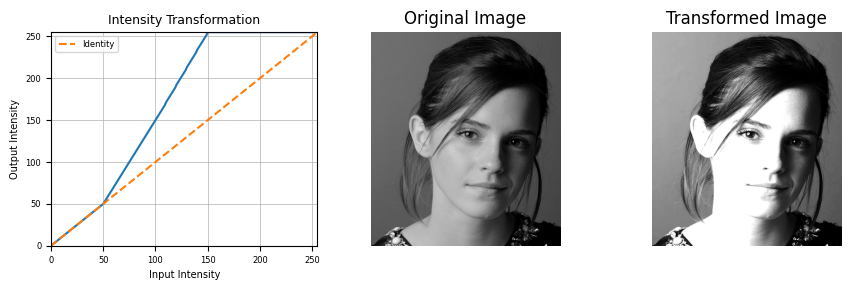

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def intensity_transform(im, breakpoints):
    transform = np.zeros(256, dtype=np.uint8)
    for i in range(len(breakpoints)-1):
        x1,y1=breakpoints[i]
        x2,y2=breakpoints[i+1]
        x=np.arange(x1,x2+1)
        y=np.linspace(y1,y2,len(x))
        transform[x]=y.astype(np.uint8)
    transformed_image=cv.LUT(im,transform)
    return transformed_image,transform
    
breakpoints=np.array([(0,0),(50,50),(100,150),(150,255),(255,255)])
im=cv.imread(r'C:\Users\shala\EN3160-Assignment1-on-Intensity-Transformations-and-Neighborhood-Filtering\images\Q1\emma.jpg',cv.IMREAD_GRAYSCALE)
transformed_image, transform = intensity_transform(im,breakpoints)   

plt.figure(figsize=(9, 3))
show_transform_graphs([breakpoints],["Intensity Transformation"],positions=[1])
show_images([im, transformed_image],["Original Image", "Transformed Image"],positions=[2, 3])
plt.tight_layout()
plt.show()

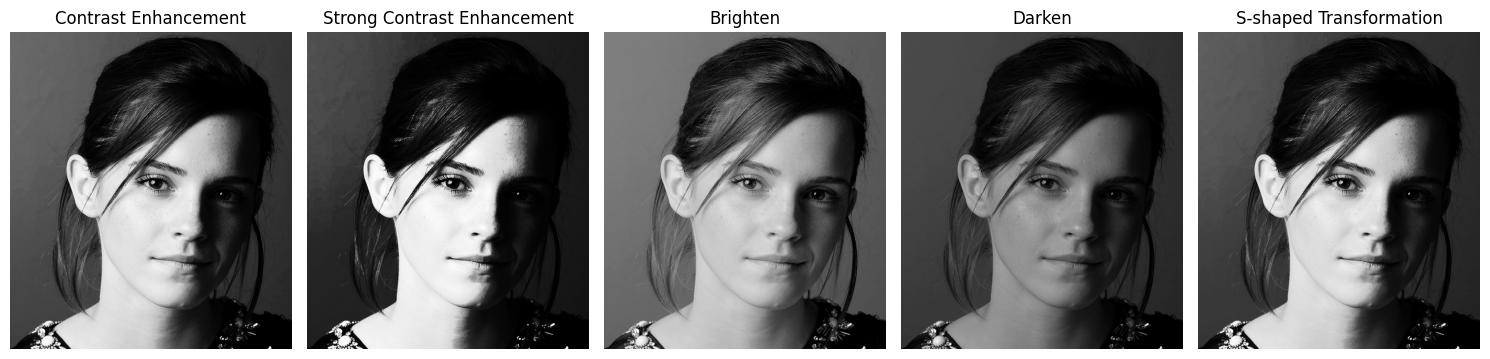

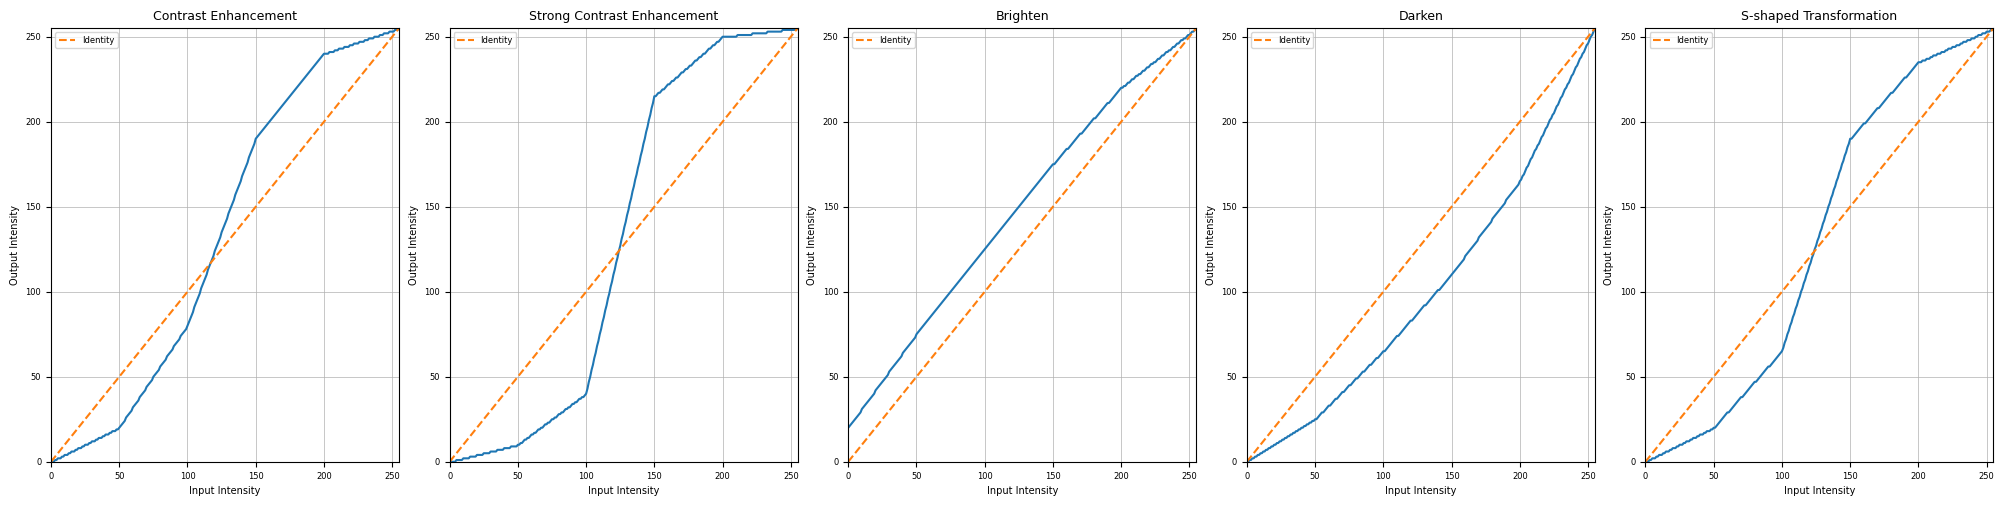

In [ ]:
# Experiment with different breakpoints
# Contrast Enhancement - increase contrast in middle/high intensity range
breakpoints1=np.array([(0,0),(50,20),(100,80),(150,190),(200,240),(255,255)])
# Strong Contrast Enhancement - Dark pixel become dark and bright pixels become bright
breakpoints2=np.array([(0,0),(50,10),(100,40),(150,215),(200,250),(255,255)])
# Brighten the image - SHifting intensity upward
breakpoints3=np.array([(0,20),(50,75),(100,125),(150,175),(200,220),(255,255)])
# Darken the imag
breakpoints4=np.array([(0,0),(50,25),(100,65),(150,110),(200,165),(255,255)])
# S-shaped transformation
breakpoints5=np.array([(0,0),(50,20),(100,65),(150,190),(200,235),(255,255)])
# Outputs
titles = ["Contrast Enhancement","Strong Contrast Enhancement","Brighten","Darken","S-shaped Transformation"]

breakpoints_list = [breakpoints1, breakpoints2, breakpoints3, breakpoints4, breakpoints5]
transformed_images = []
for bp in breakpoints_list:
    # Apply transformation
    transformed, transform = intensity_transform(im, bp)
    transformed_images.append(transformed)

show_images(transformed_images,titles,figsize=(15, 4))
show_transform_graphs(breakpoints_list,titles,figsize=(20,5))

Appearance of the transformed image is controlled by the choice and position of break points. Moving output values upward brightens the image, moving downward darken the image and increasing the difference between output values enhance the contrast. S-shaped and strong contrast will enhance middle intensity details

#### Question 2 

Minimum intensity:  0
Maximum intensity:  255


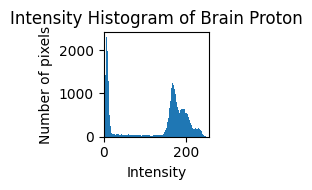

In [ ]:
im2=cv.imread(r'C:\Users\shala\EN3160-Assignment1-on-Intensity-Transformations-and-Neighborhood-Filtering\images\Q2\brain proton.jpeg',cv.IMREAD_GRAYSCALE)
print("Minimum intensity: ",im.min())
print("Maximum intensity: ",im.max())

# Histogram
show_histogram(im2,"Intensity Histogram of Brain Proton",figsize=(2, 2))

White matter - 150 - 180 <br>
Gray matter - 180 - 200

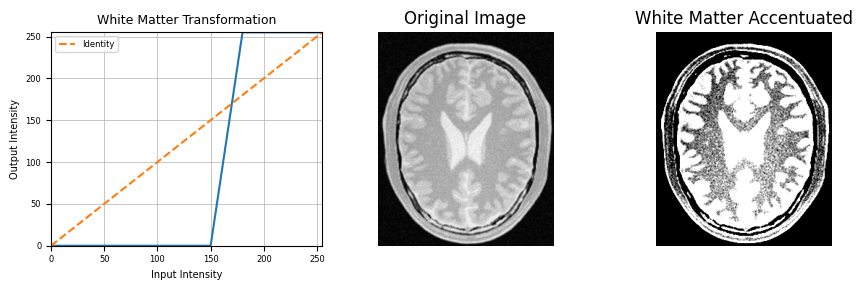

In [ ]:
wm_breakpoints=[(0,0),(150,0),(180,255),(255,255)]
wm_image,wm_transform=intensity_transform(im2, wm_breakpoints)
plt.figure(figsize=(9, 3))
show_transform_graphs([wm_breakpoints],["White Matter Transformation"],positions=[1])
show_images([im2, wm_image],["Original Image", "White Matter Accentuated"],positions=[2, 3])
plt.tight_layout()
plt.show()

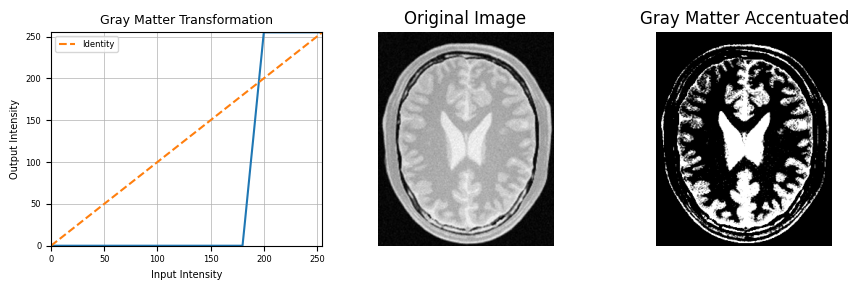

In [ ]:
gm_breakpoints=[(0,0),(180,0),(200,255),(255,255)]
gm_image,gm_transform=intensity_transform(im2, gm_breakpoints)

plt.figure(figsize=(9, 3))
show_transform_graphs([gm_breakpoints],["Gray Matter Transformation"],positions=[1])
show_images([im2, gm_image],["Original Image", "Gray Matter Accentuated"],positions=[2, 3])
plt.tight_layout()
plt.show()

Here, We emphasize specific tissues based on their intensity values by expanding a relatively narrow intensity range while suppressing others.

#### Question 3 - Apply Gamma Correction

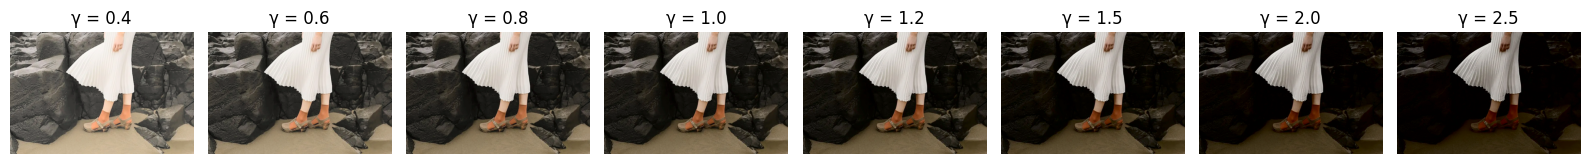

In [ ]:
im3 = cv.imread(r'C:\Users\shala\EN3160-Assignment1-on-Intensity-Transformations-and-Neighborhood-Filtering\images\Q3\img3.webp')
# convert BGR to Lab
lab=cv.cvtColor(im3,cv.COLOR_BGR2LAB)
# L channel
L=lab[:,:,0]
# separate L*, a*, b*
L,a,b = cv.split(lab)
gamma_values=[0.4, 0.6, 0.8, 1.0, 1.2, 1.5, 2.0, 2.5]
corrected_images = []
for i, gamma in enumerate(gamma_values):
    # Normalize and gamma correction
    L_norm=L/255.0
    L_gamma_corrected=np.power(L_norm,gamma)
    L_gamma_corrected=np.uint8(L_gamma_corrected*255)
    # combine L* with a* and b*
    corrected_lab=cv.merge([L_gamma_corrected,a,b])
    corrected_bgr=cv.cvtColor(corrected_lab,cv.COLOR_LAB2BGR)
    corrected_images.append(corrected_bgr)

show_images(corrected_images,[f"γ = {gamma}" for gamma in gamma_values],figsize=(16, 8))    


Plotting Histogram

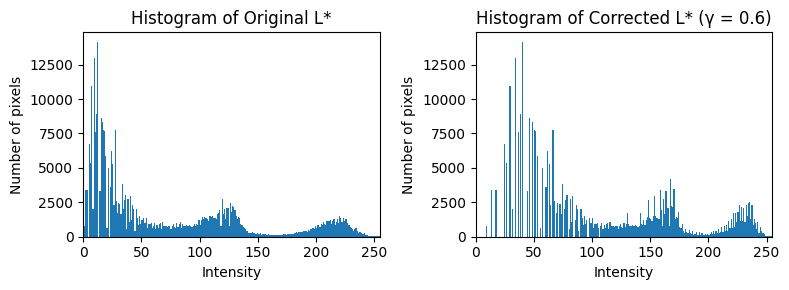

In [ ]:
gamma=0.6
# Gamma correction
L_norm = L / 255.0
L_gamma = np.power(L_norm, gamma)
L_gamma = np.uint8(L_gamma * 255)

plt.figure(figsize=(8, 3))
show_histogram(L,"Histogram of Original L*",positions=1)
show_histogram(L_gamma,f"Histogram of Corrected L* (γ = {gamma})",positions=2)
plt.tight_layout()
plt.show()

Here, Gamma correction was applied to L* plane. Gamma=0.6 gives a visually pleasing output. Since gamma < 1, the transformation brightens the image, specially the darker and midtone regions. The a* and b* channels were unchanged, preserving the color information.

#### Question 4

In [ ]:
im4=cv.imread(r'C:\Users\shala\EN3160-Assignment1-on-Intensity-Transformations-and-Neighborhood-Filtering\images\Q4\spiderman.png')

# Convert BGR to HSV
hsv=cv.cvtColor(im4, cv.COLOR_BGR2HSV)
# Split into HSV
H,S,V=cv.split(hsv)

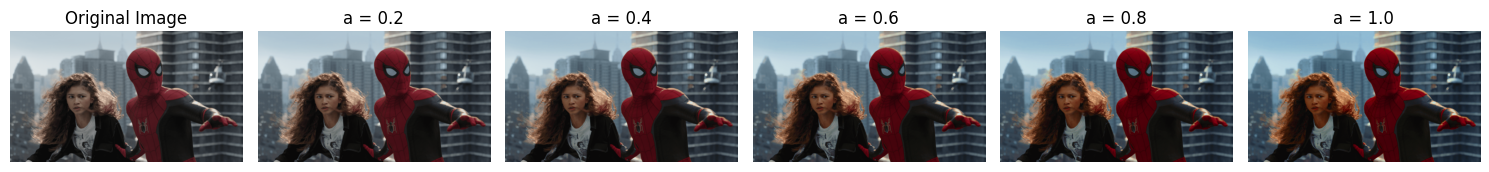

In [ ]:
sigma=70

def vibrance_transform(S,a,sigma=70):
    S_float=S.astype(np.float32)
    S_new=S_float+(a*128*np.exp(-((S_float-128)**2)/(2*sigma**2)))
    S_new=np.clip(S_new,0,255)
    return S_new.astype(np.uint8)

a_values=[0.2,0.4,0.6,0.8,1.0]
enhanced_images=[]

for a in a_values:
    #Transform Saturation
    S_new=vibrance_transform(S,a,sigma)
    # Recombine H, modified H and s
    hsv_new=cv.merge([H,S_new,V])
    #HSV->BGR
    enhanced=cv.cvtColor(hsv_new,cv.COLOR_HSV2BGR)
    enhanced_images.append(enhanced)

show_images([im4] + enhanced_images,["Original Image"] + [f"a = {a}" for a in a_values],figsize=(15, 7))

a=0.8

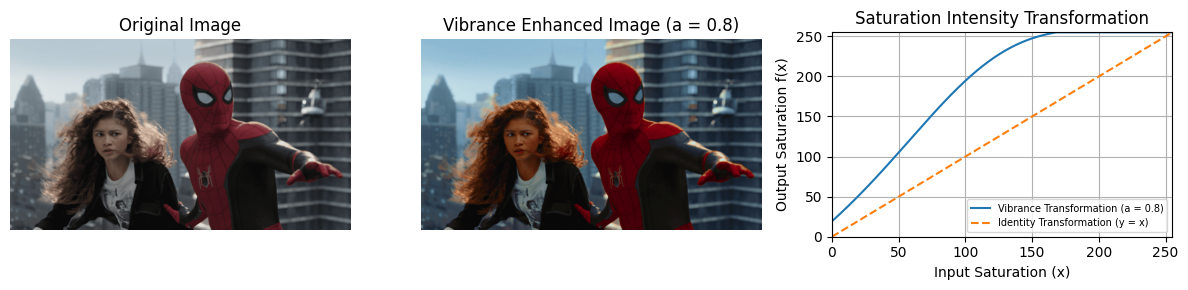

In [ ]:
a=0.8
hsv_enhanced = cv.merge([H, S_new, V])
enhanced = cv.cvtColor(hsv_enhanced,cv.COLOR_HSV2BGR)
x=np.arange(256,dtype=np.float32)
f_x=x+(a*128*np.exp(-((x-128)**2)/(2*sigma**2)))
f_x=np.clip(f_x,0,255)

plt.figure(figsize=(12, 3))
show_images([im4],["Original Image"],positions=[1])
show_images([enhanced],[f"Vibrance Enhanced Image (a = {a})"],positions=[2])
plt.subplot(1, 3, 3)
plt.plot(x, f_x, label=f'Vibrance Transformation (a = {a})')
plt.plot(x, x, '--', label='Identity Transformation (y = x)')
plt.xlabel("Input Saturation (x)")
plt.ylabel("Output Saturation f(x)")
plt.title("Saturation Intensity Transformation")
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid(True)
plt.legend(fontsize=7)
plt.tight_layout()
plt.show()

Here, Saturation(S) plane was enhanced using the given intensity transformation. a=0.8 gives a visually pleasing output. To get more vibrant image while preserving hue and brightness, it combines modified S plane to the original H and V plane.

#### Question 5 - Histogram Equalization Function

In [ ]:
def histogram_equalization(im):
    L=256
    M,N=im.shape
    hist=np.bincount(im.ravel(),minlength=L)
    cdf=hist.cumsum()
    t=((L-1)/(M*N))*cdf
    # convert to integer
    t=np.round(t).astype(np.uint8)
    g=t[im]
    return g, hist, t

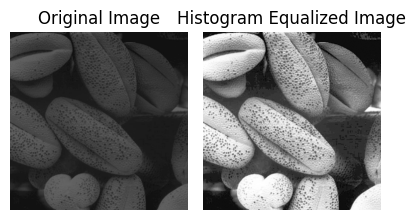

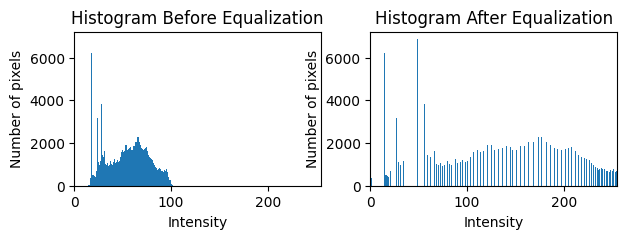

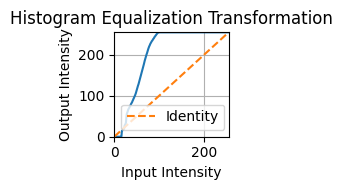

In [ ]:
im_orig=im5=cv.imread(r'c:\Users\shala\OneDrive\Pictures\Screenshots 1\Screenshot 2026-09-12 223154.png')
im5=cv.imread(r'c:\Users\shala\OneDrive\Pictures\Screenshots 1\Screenshot 2026-09-12 223154.png',cv.IMREAD_GRAYSCALE)

equalized, hist_before, transform = histogram_equalization(im5)
hist_after = np.bincount(equalized.ravel(),minlength=256)

show_images([im_orig, equalized],["Original Image", "Histogram Equalized Image"],figsize=(4,4))
plt.figure(figsize=(7,2))
show_histogram(im5,"Histogram Before Equalization",positions=1)
show_histogram(equalized,"Histogram After Equalization",positions=2)
r = np.arange(256)
plt.figure(figsize=(2,2))
plt.plot(r, transform)
plt.plot([0, 255], [0, 255], '--', label='Identity')
plt.xlabel("Input Intensity")
plt.ylabel("Output Intensity")
plt.title("Histogram Equalization Transformation")
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Here, image contrast was improved by redistributing its intensity values using histogram equalization. The histogram after equalization is spread over a wider intensity range compared with the original histogram. As a result, the equalized image has better contrast and more visible details in similar intensity levels.

#### Question 6

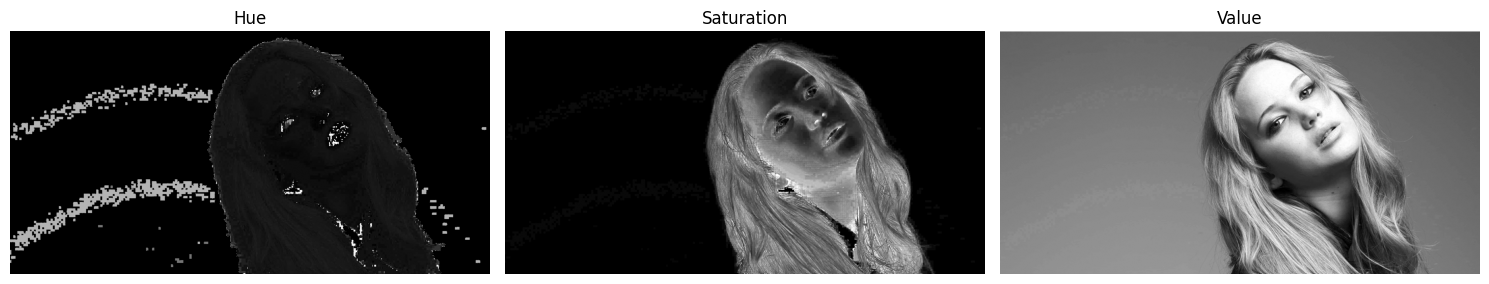

In [ ]:
# Part a
im6=cv.imread(r'C:\Users\shala\EN3160-Assignment1-on-Intensity-Transformations-and-Neighborhood-Filtering\images\Q6\Q6.png')
#convert BGR to HSV
hsv=cv.cvtColor(im6,cv.COLOR_BGR2HSV)
#Split
# H - Type of Colour  S - Colour Intensity   V - Brightness
H,S,V=cv.split(hsv)
show_images([H, S, V],["Hue", "Saturation", "Value"],figsize=(15, 4))

Threshold: 61


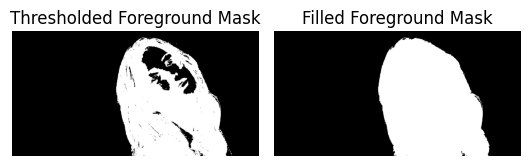

In [ ]:
# Part b
threshold, mask = cv.threshold(S,0,255,cv.THRESH_BINARY+cv.THRESH_OTSU)
print(f"Threshold: {threshold:.0f}")
#find external contour
contours, _=cv.findContours(mask,cv.RETR_EXTERNAL,cv.CHAIN_APPROX_SIMPLE)
largest=max(contours,key=cv.contourArea)
empty_mask=np.zeros_like(mask)
cv.drawContours(empty_mask,[largest],-1,255,thickness=cv.FILLED)
plt.figure(figsize=(8,3))
show_images([mask],["Thresholded Foreground Mask"],positions=[1])
show_images([empty_mask],["Filled Foreground Mask"],positions=[2])
plt.tight_layout()
plt.show()

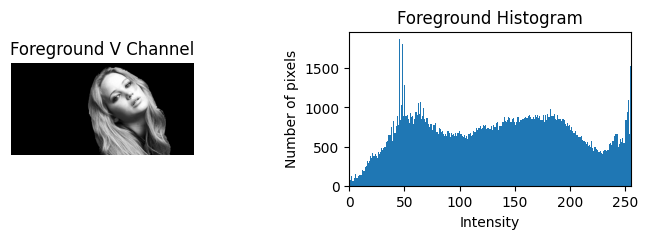

In [ ]:
# Part c
# Exact V in foreground
foreground=cv.bitwise_and(V,V,mask=empty_mask)
fg_values = foreground[empty_mask > 0]
hist = np.bincount(fg_values,minlength=256)
plt.figure(figsize=(8,2))
show_images([foreground],["Foreground V Channel"],positions=[1])
show_histogram(foreground[empty_mask>0],"Foreground Histogram",positions=2)
plt.show()

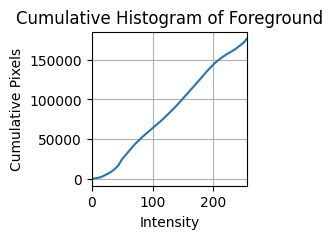

In [ ]:
# Part d
cdf=np.cumsum(hist)
plt.figure(figsize=(2,2))
plt.plot(cdf)
plt.title('Cumulative Histogram of Foreground')
plt.xlabel('Intensity')
plt.ylabel('Cumulative Pixels')
plt.xlim(0, 255)
plt.grid()
plt.show()

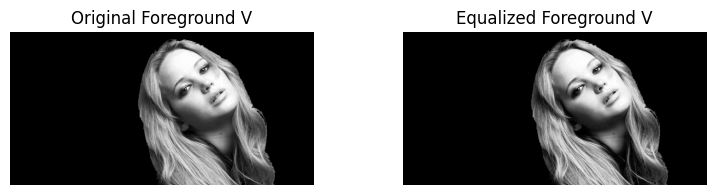

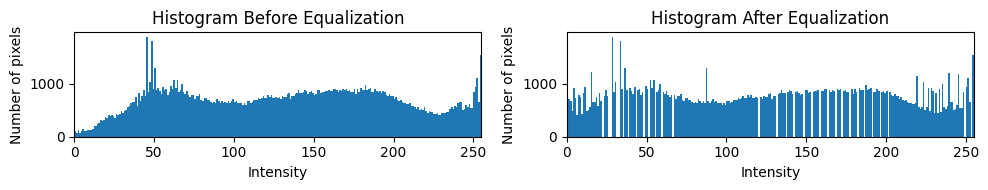

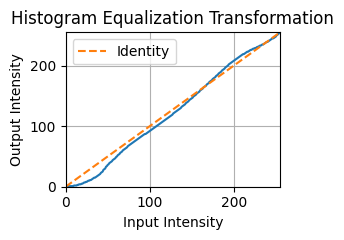

In [ ]:
# Part e
L = 256
cdf_non_zero=cdf[cdf>0]
cdf_min=cdf_non_zero[0]
no_f_pixels=len(fg_values)
lut = np.round(((cdf - cdf_min) / (no_f_pixels - cdf_min)) * 255)
lut = np.clip(lut,0,255).astype(np.uint8)
#Apply equilization to foreground
V_equilized = V.copy()
f_pixels=empty_mask>0
V_equilized[f_pixels]=lut[V[f_pixels]]
foreground_V_equilized = cv.bitwise_and(V_equilized,V_equilized,mask=empty_mask)
fg_eq_values = foreground_V_equilized[empty_mask > 0]
hist_eq = np.bincount(fg_eq_values,minlength=256)

show_images([foreground, foreground_V_equilized],["Original Foreground V", "Equalized Foreground V"],figsize=(8,2))
plt.figure(figsize=(10,2))
show_histogram(fg_values,"Histogram Before Equalization",positions=1)
show_histogram(fg_eq_values,"Histogram After Equalization",positions=2)
plt.tight_layout()
plt.show()
plt.figure(figsize=(3,2.5))
plt.plot(np.arange(256),lut)
plt.plot([0,255],[0,255],'--',label='Identity')
plt.xlabel('Input Intensity')
plt.ylabel('Output Intensity')
plt.title('Histogram Equalization Transformation')
plt.xlim(0,255)
plt.ylim(0,255)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

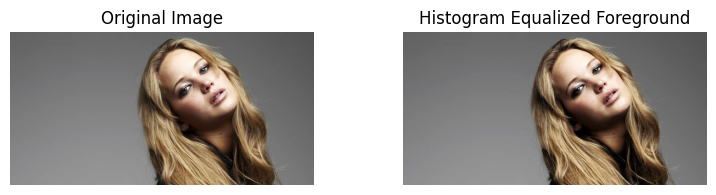

In [ ]:
# part f
hsv_equilized = cv.merge([H,S,V_equilized])

# Convert HSV to RGB for displaying with matplotlib
result_rgb = cv.cvtColor(hsv_equilized,cv.COLOR_HSV2RGB)

plt.figure(figsize=(8,2))
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(im6, cv.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(result_rgb)
plt.title('Histogram Equalized Foreground')
plt.axis('off')

plt.tight_layout()
plt.show()

Here, saturation plane was thresholded using Otsu’s method to obtain the foreground mask. The Value (V) plane was selected for histogram equalization because it represents the brightness information. The equalized foreground was then combined with the original background to improve the contrast in the foreground.

#### Question 7

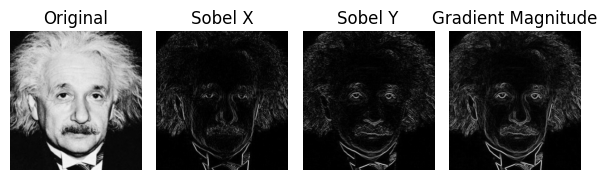

In [ ]:
#Part a
im7=cv.imread(r'C:\Users\shala\EN3160-Assignment1-on-Intensity-Transformations-and-Neighborhood-Filtering\images\Q7\Albert.png',cv.IMREAD_GRAYSCALE)
sobel_x = np.array([[1, 0, -1],[2, 0, -2],[1, 0, -1]], dtype=np.float32)
sobel_y = np.array([[1, 2, 1],[0, 0, 0],[-1, -2, -1]], dtype=np.float32)
Gx = cv.filter2D(im7.astype(np.float32), cv.CV_32F, sobel_x)
Gy = cv.filter2D(im7.astype(np.float32), cv.CV_32F, sobel_y)
magnitude = np.sqrt(Gx**2 + Gy**2)
magnitude_display = cv.normalize(magnitude, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)
show_images([im7,np.abs(Gx),np.abs(Gy),magnitude_display],["Original","Sobel X","Sobel Y","Gradient Magnitude"],figsize=(6,2))


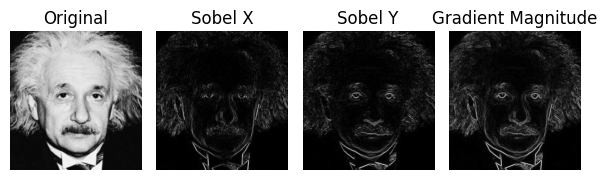

In [ ]:
# Part b
def mannual_filter(im, k): 
    im = im.astype(np.float32) 
    k = np.asarray(k, dtype=np.float32)    
    kh, kv = k.shape 
    h = kh // 2 
    v = kv // 2     
    padded = np.pad(im, ((h, h), (v, v)), mode="reflect")
    out = np.zeros_like(im, dtype=np.float32) 
    for i in range(im.shape[0]): 
        for j in range(im.shape[1]): 
            region = padded[i:i+kh, j:j+kv] 
            out[i, j] = np.sum(region * k) 
    return out 
Gx_manual = mannual_filter(im7, sobel_x) 
Gy_manual = mannual_filter(im7, sobel_y)
Gx_display = cv.normalize(np.abs(Gx_manual), None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)
Gy_display = cv.normalize(np.abs(Gy_manual), None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)
magnitude_manual = np.sqrt(Gx_manual**2 + Gy_manual**2)
magnitude_manual_display = cv.normalize(magnitude_manual,None,0,255,cv.NORM_MINMAX).astype(np.uint8)
show_images([im7, Gx_display, Gy_display, magnitude_manual_display],["Original", "Sobel X", "Sobel Y", "Gradient Magnitude"],figsize=(6,2))

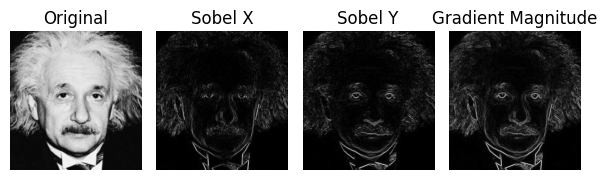

In [ ]:
#Part c
# 1D Sobel kernels
smooth = np.array([[1, 2, 1]], dtype=np.float32)
derivative = np.array([[1, 0, -1]], dtype=np.float32)

temp_x = mannual_filter(im7, smooth.T)
Gx_sep = mannual_filter(temp_x, derivative)

temp_y = mannual_filter(im7, derivative.T)
Gy_sep = mannual_filter(temp_y, smooth)
# Gradient magnitude
magnitude_sep = np.sqrt(Gx_sep**2 + Gy_sep**2)
# Normalize for display
Gx_sep_display = cv.normalize(np.abs(Gx_sep), None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)
Gy_sep_display = cv.normalize(np.abs(Gy_sep), None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)
magnitude_sep_display = cv.normalize(magnitude_sep, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)
# Display
show_images([im7, Gx_sep_display, Gy_sep_display, magnitude_sep_display],["Original", "Sobel X", "Sobel Y", "Gradient Magnitude"],figsize=(6,2))

Sobel operator is used to detect the intensity changes and edges in the image. cv.filter2D was used with Sobel kernals to obtain the horizontal and vertical gradients. Sobel kernels were separated into 1D smoothing and derivative filters to reduce the computational complexity while producing similar edge information. Gradient magnitude will use to show the overall edge strength.

#### Question 8

In [ ]:
def zoom_image(image, scale, method="nearest"):
    if scale <= 0 or scale > 10:
        raise ValueError("Scale factor must be in the range (0, 10].")
    height, width = image.shape[:2]
    new_height = int(round(height * scale))
    new_width = int(round(width * scale))
    # Create output image
    if len(image.shape) == 3:
        output = np.zeros((new_height, new_width, image.shape[2]),dtype=image.dtype)
    else:
        output = np.zeros((new_height, new_width),dtype=image.dtype)
    for y in range(new_height):
        for x in range(new_width):
            # Corresponding position in original image
            src_y = y / scale
            src_x = x / scale
            if method == "nearest":
                # Nearest-neighbor interpolation
                iy = int(round(src_y))
                ix = int(round(src_x))
                # Keep coordinates inside image
                iy = min(iy, height - 1)
                ix = min(ix, width - 1)
                output[y, x] = image[iy, ix]
            
            elif method == "bilinear":
                # Coordinates of four neighboring pixels
                y0 = int(np.floor(src_y))
                x0 = int(np.floor(src_x))
                y1 = min(y0 + 1, height - 1)
                x1 = min(x0 + 1, width - 1)
                # Make sure starting coordinates are valid
                y0 = min(y0, height - 1)
                x0 = min(x0, width - 1)
                # Distance from top-left pixel
                dy = src_y - y0
                dx = src_x - x0
                
                # Four neighboring pixels
                top_left = image[y0, x0]
                top_right = image[y0, x1]
                bottom_left = image[y1, x0]
                bottom_right = image[y1, x1]
                # Bilinear interpolation
                output[y, x] = (top_left * (1 - dx) * (1 - dy) +top_right * dx * (1 - dy) +bottom_left * (1 - dx) * dy +bottom_right * dx * dy)
            else:
                raise ValueError("Method must be 'nearest' or 'bilinear'.")
    return output

#Normalize
def normalized_ssd(original, zoomed):
    original = original.astype(np.float64)
    zoomed = zoomed.astype(np.float64)
    ssd = np.sum((original - zoomed) ** 2)
    normalization = np.sum(original ** 2)
    return ssd / normalization

In [ ]:
original1 = cv.imread(r'C:\Users\shala\EN3160-Assignment1-on-Intensity-Transformations-and-Neighborhood-Filtering\images\Q8\im01.png')
small1 = cv.imread(r'C:\Users\shala\EN3160-Assignment1-on-Intensity-Transformations-and-Neighborhood-Filtering\images\Q8\im01small.png')
original2 = cv.imread(r'C:\Users\shala\EN3160-Assignment1-on-Intensity-Transformations-and-Neighborhood-Filtering\images\Q8\im02.png')
small2 = cv.imread(r'C:\Users\shala\EN3160-Assignment1-on-Intensity-Transformations-and-Neighborhood-Filtering\images\Q8\im02small.png')

zoom_nearest1 = zoom_image(small1, 4, "nearest")
zoom_bilinear1 = zoom_image(small1, 4, "bilinear")
zoom_nearest2 = zoom_image(small2, 4, "nearest")
zoom_bilinear2 = zoom_image(small2, 4, "bilinear")

print(original1.shape, zoom_nearest1.shape)
print(original2.shape, zoom_nearest2.shape)

ssd_n1 = normalized_ssd(original1, zoom_nearest1)
ssd_b1 = normalized_ssd(original1, zoom_bilinear1)
ssd_n2 = normalized_ssd(original2, zoom_nearest2)
ssd_b2 = normalized_ssd(original2, zoom_bilinear2)

print("Image 1 - Nearest Neighbor SSD:", ssd_n1)
print("Image 1 - Bilinear SSD:", ssd_b1)
print("Image 2 - Nearest Neighbor SSD:", ssd_n2)
print("Image 2 - Bilinear SSD:", ssd_b2)

show_images(
    [original1, small1, zoom_nearest1, zoom_bilinear1],
    ["Original", "Small", "Nearest", "Bilinear"],
    figsize=(10, 3)
)

show_images(
    [original2, small2, zoom_nearest2, zoom_bilinear2],
    ["Original", "Small", "Nearest", "Bilinear"],
    figsize=(10, 3)
)

Nearest-neighbor interpolation produces sharper but more pixelated results, while bilinear interpolation produces smoother images. The normalized SSD was calculated by comparing each zoomed image with its corresponding original image. The method with the lower normalized SSD provides a result that is more similar to the original image.

#### Question 9 - GrabCut segmentation

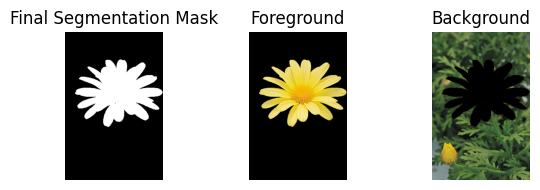

In [ ]:
#Part a - GrabCut Segmentation

im9 = cv.imread(r'C:\Users\shala\EN3160-Assignment1-on-Intensity-Transformations-and-Neighborhood-Filtering\images\Q9\flower.png')
# Create initial mask
mask = np.zeros(im9.shape[:2], np.uint8)
# Rectangle around the flower
x, y, w, h = 20, 20, im9.shape[1] - 20, im9.shape[0] - 120
# GrabCut models
bg_model = np.zeros((1, 65), np.float64)
fg_model = np.zeros((1, 65), np.float64)
# Apply GrabCut
cv.grabCut(im9,mask,(x, y, w, h),bg_model,fg_model,5,cv.GC_INIT_WITH_RECT)
# Create final binary foreground mask
final_mask = np.where((mask == cv.GC_FGD) | (mask == cv.GC_PR_FGD),255,0).astype(np.uint8)
# Extract foreground
foreground = cv.bitwise_and(im9,im9,mask=final_mask)
# Extract background
background_mask = cv.bitwise_not(final_mask)
background = cv.bitwise_and(im9,im9,mask=background_mask)

show_images([final_mask, foreground, background],["Final Segmentation Mask", "Foreground", "Background"],figsize=(6,2))

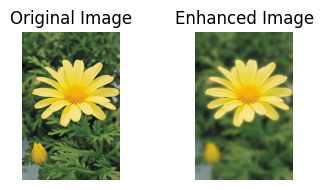

In [ ]:
#Part b-Blur the background
blurred = cv.GaussianBlur(im9,(31, 31),0)
enhanced = np.where(final_mask[:, :, None] == 255,im9,blurred).astype(np.uint8)
show_images([im9, enhanced],["Original Image", "Enhanced Image"],figsize=(4,2))

##### Why is the background just beyond the edge of the flower quite dark in the enhanced image?<br>
Because Gaussian blurring averages neighboring background pixels. During the blur, dark background pixels near the flower boundary spread into surrounding pixels. Also, the GrabCut segmentation boundary may not perfectly match the actual flower edge. It produces a dark halo where the original foreground is combined with the blurred background.

#### Question 10

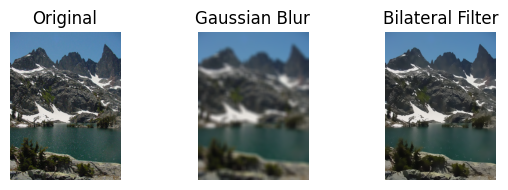

In [ ]:
#Part a
im10 = cv.imread(r'C:\Users\shala\EN3160-Assignment1-on-Intensity-Transformations-and-Neighborhood-Filtering\images\Q10\q10.png')
# Parameters
d = 21
sigma_s = 10
sigma_r = 50

# Gaussian blur
gaussian = cv.GaussianBlur(im10,(d, d), sigmaX=sigma_s)
# Bilateral filter
bilateral = cv.bilateralFilter(im10,d=d,sigmaColor=sigma_r,sigmaSpace=sigma_s)
# Display
show_images([im10, gaussian, bilateral],["Original", "Gaussian Blur", "Bilateral Filter"],figsize=(6,2))

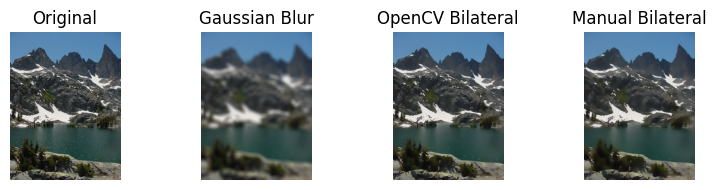

In [ ]:
#Part b
def manual_bilateral_filter(im,d,sigma_s,sigma_r):
    im=im.astype(np.float32)
    r=d//2
    padded=np.pad(im,((r,r),(r,r),(0,0)),mode="reflect")
    out=np.zeros_like(im)
    y,x=np.mgrid[-r:r+1,-r:r+1]
    weight=np.exp(-(x**2+y**2)/(2*sigma_s**2))
    h,v=im.shape[:2]

    for i in range(h):
        for j in range(v):
            patch = padded[i:i + d,j:j + d]
            center = im[i, j]
            # BGR squared Euclidean distance
            color_diff_sq = np.sum((patch - center) ** 2,axis=2)
            # Range weights
            range_weights = np.exp(-color_diff_sq / (2 * sigma_r**2))
            # Combined weights
            weights = weight * range_weights
            # Normalize
            weight_sum = np.sum(weights)
            # Weighted average
            out[i, j] = np.sum(patch * weights[:, :, None],axis=(0, 1)) / weight_sum
    return np.clip(out, 0, 255).astype(np.uint8)

manual_bilateral = manual_bilateral_filter(im10,d=d,sigma_s=sigma_s,sigma_r=sigma_r)
show_images([im10,gaussian,bilateral,manual_bilateral],["Original","Gaussian Blur","OpenCV Bilateral","Manual Bilateral"],figsize=(8,2))

In [ ]:
def compare(im1, im2):
    mse = np.mean((im1.astype(float) - im2.astype(float))**2)
    nmse = np.sum((im1.astype(float) - im2.astype(float))**2) / np.sum(im1.astype(float)**2)
    psnr = 10 * np.log10(255**2 / mse)
    return mse, nmse, psnr

mse, nmse, psnr = compare(bilateral, manual_bilateral)

print("MSE:", mse)
print("NMSE:", nmse)
print("PSNR:", psnr, "dB")

MSE: 16.310912969359432
NMSE: 0.0016693506215454013
PSNR: 36.00602090418795 dB


The Gaussian filter smooths the image effectively but it blurs important edges. But the bilateral filter smooths homogeneous regions while preserving edges by considering both spatial distance and intensity differences. Lower MSE/NMSE and higher PSNR indicate greater similarity between the openCV's bilateral filter and manual bilateral filter.